## ST-GNN Model for Pharmacy Desert Risk Prediction
# Week 4 – Spatial-Temporal Modeling

# Loading Data

Importing the merged dataset

In [2]:
import pandas as pd
import numpy as np

# Data Importation
# Getting cleaned and merged per state data
df = pd.read_csv("df_final_pharmacy_cleaned.csv")
# Getting Overview
df.head()


,State_y,County,county_fips,year,pharmacies_per_county_year,tot_claims,tot_30day_fills,tot_drug_cost,tot_days_supply,tot_beneficiaries,avg_bene_age,Health_Outcome_Rank,Health_Factor_Rank,labor_force,employed,unemployed,unemployment_rate
0,AK,Aleutians East,2013,2014,0,1543,2515.200000,101236.20,69125,252,72.206522,16.0,16.0,2219,2121,98,4.4
1,AK,Aleutians East,2013,2015,1,1265,2095.733333,87137.34,58674,211,70.535299,16.0,16.0,2472,2395,77,3.1
2,AK,Aleutians East,2013,2016,2,1977,3104.066667,144648.87,84565,250,66.715694,16.0,16.0,2589,2523,66,2.5
3,AK,Aleutians East,2013,2018,2,1451,2550.366667,112767.33,67572,435,69.874315,16.0,16.0,2316,2250,66,2.8
4,AK,Aleutians East,2013,2019,1,92,136.433333,11567.95,2963,42,70.142857,16.0,16.0,2544,2483,61,2.4


# Feature Engineering

Data Preprocessing for Spatial-Temporal Neural Network - Spatial-Temporal Graph Neural Network (ST-GNN).

## Feature Engineering for Target: Desert Formation Risk

**Pharmacy Accessibility Pressure (PAP) Index** - measures the beneficiary load per pharmacy by dividing the total number of beneficiaries (tot_beneficiaries) by the total number of pharmacies in the given county.

**Temporal Desert Formation (TDF) Feature** - Tracks the percentage change in the **Pharmacy Accessibility Pressure (PAP) Index** across years for each of the counties.

**Desert_Formation_Risk** - Binary feature for a county as either at high risk or low risk of pharmacy desert formation based on the percentage change in the Pharmacy Accessibility Pressure (PAP) Index (≥25% change = High Risk, otherwise Low Risk).



In [3]:
# Creating the Pharmacy Accessibility Pressure Index (PAPI)
df["bene_per_pharmacy_PAP"] = (
    df["tot_beneficiaries"] /
    df["pharmacies_per_county_year"]
)

# Creating a lag for Accessibility Pressure Index
df["bene_per_pharmacy_PAP_lag"] = (
    df.groupby("county_fips")["bene_per_pharmacy_PAP"]
      .shift(1)
)


# Creating Temporal Desert Formation Feature
df["access_pressure_change_TDF"] = (
    (df["bene_per_pharmacy_PAP"] - df["bene_per_pharmacy_PAP_lag"])/df["bene_per_pharmacy_PAP_lag"]
)



In [4]:
# Pharmacy Desert Formation Risk Feature

df["Desert_Formation_Risk"] = np.where(
    df["access_pressure_change_TDF"] >= 0.25,
    "High Risk",
    "Low Risk"
)


In [5]:
# Replace inf and -inf with NaN
df = df.replace([np.inf, -np.inf], np.nan)


## Creating Queen Spatial Lag features

In [6]:
%pip install geopandas

In [7]:
# Getting County Geometry Data

import geopandas as gpd

# Importing county level shape file
counties = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_500k.zip"
)
print(counties.head())

  STATEFP COUNTYFP  COUNTYNS         GEOIDFQ  GEOID     NAME        NAMELSAD  \
0      01      003  00161527  0500000US01003  01003  Baldwin  Baldwin County   
1      01      069  00161560  0500000US01069  01069  Houston  Houston County   
2      01      005  00161528  0500000US01005  01005  Barbour  Barbour County   
3      01      119  00161585  0500000US01119  01119   Sumter   Sumter County   
4      05      091  00069166  0500000US05091  05091   Miller   Miller County   

  STUSPS STATE_NAME LSAD       ALAND      AWATER  \
0     AL    Alabama   06  4117725048  1132887203   
1     AL    Alabama   06  1501742235     4795415   
2     AL    Alabama   06  2292160151    50523213   
3     AL    Alabama   06  2340898915    24634880   
4     AR   Arkansas   06  1616257232    36848741   

                                            geometry  
0  POLYGON ((-88.02858 30.22676, -88.02399 30.230...  
1  POLYGON ((-85.71209 31.19727, -85.70934 31.198...  
2  POLYGON ((-85.74803 31.61918, -85.7454

In [8]:
# Correcting the county fips in the pharmacy dataset to ensure a leading 0 is added to the fips where necessary
df['county_fips'] = (
    df['county_fips']
    .astype(str)
    .str.zfill(5)
)
# Ensuring data type alignment in counties geometry data
counties['GEOID'] = (
    counties['GEOID']
    .astype(str)
    .str.zfill(5)
)

In [9]:
%pip install libpysal

In [10]:
# Creating Queen's contiguity spatial weights
from libpysal.weights import Queen

w = Queen.from_dataframe(
    counties,
    ids='GEOID'
)

print(w.n)
print(w.neighbors[list(w.neighbors.keys())[0]])

3235
['01129', '01053', '01099', '01025', '12033', '01097']


/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 26 disconnected components.
 There are 21 islands with ids: 15003, 15007, 69110, 78020, 25007, 53055, 60020, 69085, 66010, 15001, 78010, 78030, 60040, 02016, 69100, 72147, 36085, 69120, 25019, 72049, 60030.
  W.__init__(self, neighbors, ids=ids, **kw)


In [11]:
# Setting up Row Standardized Spatial Weights
w.transform = 'R'

# Variables for spatial lagging
spatial_vars = [

    'access_pressure_change_TDF',

    'tot_claims',

    'tot_drug_cost',

    'unemployment_rate',

    'tot_beneficiaries'
]

# Creating yearly Queen spatial lags for the variables of interest

from libpysal.weights import Queen, lag_spatial


lagged_frames = []


for yr in sorted(df['year'].unique()):

    temp = df[df['year'] == yr].copy()

    # collapsing duplicates per county
    temp = temp.groupby('county_fips', as_index=False).mean(numeric_only=True)

    # merge geometry
    temp = counties[['GEOID', 'geometry']].merge(
        temp,
        left_on='GEOID',
        right_on='county_fips',
        how='inner'
    )

    # ensure unique IDs (CRITICAL)
    temp = temp.drop_duplicates(subset='GEOID')

    temp = temp.sort_values('GEOID').reset_index(drop=True)

    # build weights
    year_w = Queen.from_dataframe(
        temp,
        ids='GEOID'
    )

    year_w.transform = "R"

    for var in spatial_vars:

        temp[f'queen_lag_{var}'] = lag_spatial(
            year_w,
            temp[var].values
        )

    lagged_frames.append(temp)

('WARNING: ', '15003', ' is an island (no neighbors)')
('WARNING: ', '15007', ' is an island (no neighbors)')
('WARNING: ', '69110', ' is an island (no neighbors)')
('WARNING: ', '78020', ' is an island (no neighbors)')
('WARNING: ', '25007', ' is an island (no neighbors)')
('WARNING: ', '53055', ' is an island (no neighbors)')
('WARNING: ', '60020', ' is an island (no neighbors)')
('WARNING: ', '69085', ' is an island (no neighbors)')
('WARNING: ', '66010', ' is an island (no neighbors)')
('WARNING: ', '15001', ' is an island (no neighbors)')
('WARNING: ', '78010', ' is an island (no neighbors)')
('WARNING: ', '78030', ' is an island (no neighbors)')
('WARNING: ', '60040', ' is an island (no neighbors)')
('WARNING: ', '02016', ' is an island (no neighbors)')
('WARNING: ', '69100', ' is an island (no neighbors)')
('WARNING: ', '72147', ' is an island (no neighbors)')
('WARNING: ', '36085', ' is an island (no neighbors)')
('WARNING: ', '69120', ' is an island (no neighbors)')
('WARNING:

/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 15 disconnected components.
 There are 11 islands with ids: 02016, 15001, 15003, 15007, 15009, 25007, 25019, 36085, 53055, 72049, 72147.
  W.__init__(self, neighbors, ids=ids, **kw)


('WARNING: ', '02016', ' is an island (no neighbors)')
('WARNING: ', '15001', ' is an island (no neighbors)')
('WARNING: ', '15003', ' is an island (no neighbors)')
('WARNING: ', '15007', ' is an island (no neighbors)')
('WARNING: ', '15009', ' is an island (no neighbors)')
('WARNING: ', '25007', ' is an island (no neighbors)')
('WARNING: ', '25019', ' is an island (no neighbors)')
('WARNING: ', '36085', ' is an island (no neighbors)')
('WARNING: ', '53055', ' is an island (no neighbors)')
('WARNING: ', '72049', ' is an island (no neighbors)')
('WARNING: ', '72147', ' is an island (no neighbors)')


/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 15 disconnected components.
 There are 11 islands with ids: 02016, 15001, 15003, 15007, 15009, 25007, 25019, 36085, 53055, 72049, 72147.
  W.__init__(self, neighbors, ids=ids, **kw)


('WARNING: ', '02016', ' is an island (no neighbors)')
('WARNING: ', '15001', ' is an island (no neighbors)')
('WARNING: ', '15003', ' is an island (no neighbors)')
('WARNING: ', '15007', ' is an island (no neighbors)')
('WARNING: ', '15009', ' is an island (no neighbors)')
('WARNING: ', '25007', ' is an island (no neighbors)')
('WARNING: ', '25019', ' is an island (no neighbors)')
('WARNING: ', '36085', ' is an island (no neighbors)')
('WARNING: ', '53055', ' is an island (no neighbors)')
('WARNING: ', '72049', ' is an island (no neighbors)')
('WARNING: ', '72147', ' is an island (no neighbors)')


...

/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 15 disconnected components.
 There are 11 islands with ids: 02016, 15001, 15003, 15007, 15009, 25007, 25019, 36085, 53055, 72049, 72147.
  W.__init__(self, neighbors, ids=ids, **kw)


('WARNING: ', '02016', ' is an island (no neighbors)')
('WARNING: ', '15001', ' is an island (no neighbors)')
('WARNING: ', '15003', ' is an island (no neighbors)')
('WARNING: ', '15007', ' is an island (no neighbors)')
('WARNING: ', '15009', ' is an island (no neighbors)')
('WARNING: ', '25007', ' is an island (no neighbors)')
('WARNING: ', '25019', ' is an island (no neighbors)')
('WARNING: ', '36085', ' is an island (no neighbors)')
('WARNING: ', '53055', ' is an island (no neighbors)')
('WARNING: ', '72049', ' is an island (no neighbors)')
('WARNING: ', '72147', ' is an island (no neighbors)')


/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 9 islands with ids: 02016, 15001, 15003, 15007, 15009, 25007, 25019, 36085, 53055.
  W.__init__(self, neighbors, ids=ids, **kw)


('WARNING: ', '02016', ' is an island (no neighbors)')
('WARNING: ', '15001', ' is an island (no neighbors)')
('WARNING: ', '15003', ' is an island (no neighbors)')
('WARNING: ', '15007', ' is an island (no neighbors)')
('WARNING: ', '15009', ' is an island (no neighbors)')
('WARNING: ', '25007', ' is an island (no neighbors)')
('WARNING: ', '25019', ' is an island (no neighbors)')
('WARNING: ', '36085', ' is an island (no neighbors)')
('WARNING: ', '53055', ' is an island (no neighbors)')
('WARNING: ', '02016', ' is an island (no neighbors)')
('WARNING: ', '15001', ' is an island (no neighbors)')
('WARNING: ', '15003', ' is an island (no neighbors)')
('WARNING: ', '15007', ' is an island (no neighbors)')
('WARNING: ', '15009', ' is an island (no neighbors)')
('WARNING: ', '25007', ' is an island (no neighbors)')
('WARNING: ', '25019', ' is an island (no neighbors)')
('WARNING: ', '36085', ' is an island (no neighbors)')
('WARNING: ', '53055', ' is an island (no neighbors)')
('WARNING:

/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 15 disconnected components.
 There are 11 islands with ids: 02016, 15001, 15003, 15007, 15009, 25007, 25019, 36085, 53055, 72049, 72147.
  W.__init__(self, neighbors, ids=ids, **kw)


In [12]:
# Combining yearly spatial lag results

spatial_lag_df = pd.concat(
    lagged_frames,
    ignore_index=True
)

print(spatial_lag_df.shape)

# Identifying generated Queen lag columns

queen_cols = [
    c
    for c in spatial_lag_df.columns
    if c.startswith('queen_lag_')
]

print(queen_cols)

# Keeping only keys + spatial lag variables

spatial_lag_df = spatial_lag_df[
    ['county_fips', 'year'] + queen_cols
]

print(spatial_lag_df.head())

# Merging spatial lag variables back to original panel

df = df.merge(
    spatial_lag_df,
    on=['county_fips', 'year'],
    how='left'
)

print(df.shape)

# Checking missing values

print(
    df[queen_cols]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

(22245, 25)
['queen_lag_access_pressure_change_TDF', 'queen_lag_tot_claims', 'queen_lag_tot_drug_cost', 'queen_lag_unemployment_rate', 'queen_lag_tot_beneficiaries']
  county_fips    year  queen_lag_access_pressure_change_TDF  \
0       01001  2014.0                                   NaN   
1       01003  2014.0                                   NaN   
2       01005  2014.0                                   NaN   
3       01007  2014.0                                   NaN   
4       01009  2014.0                                   NaN   

   queen_lag_tot_claims  queen_lag_tot_drug_cost  queen_lag_unemployment_rate  \
0         582126.000000             4.384596e+07                     8.540000   
1         894515.333333             7.140206e+07                     9.150000   
2         203567.375000             1.173513e+07                     8.050000   
3         727194.041667             5.338642e+07                     7.450000   
4         851820.541667             6.217652e+07  

# Modeling - Spatial-Temporal Graph Neural Network (ST-GNN)

## Target and Features

**The code below defines the target variable as** ```Desert_Formation_Risk``` as a binary classification task - predicting whether a county is at high risk or low risk of pharmacy desert formation based on the percentage change in the Pharmacy Accessibility Pressure (PAP) Index (≥25% change = High Risk, otherwise Low Risk).

**Features:**

**'tot_claims'** (consumer demand for total number of customers),

**'tot_30day_fills'** (service demand and profitability indicator),

**'tot_drug_cost'** (profitability indicator for cost of drugs bought),

**'tot_days_supply'** (operations indicator on ability to meet demand for drugs),

**'tot_beneficiaries'** (consumer demand for total number of customers),

**'avg_bene_age'** (customer characteristic in terms of age),

**'Health_Outcome_Rank'** (the rank of how healthy the county in which a pharmacy is located is),

**'Health_Factor_Rank'** (the rank of the health risks for the county in which a pharmacy is located is),

**'unemployment_rate'** (macroeconomic indicator for average purchasing power of population in the county),

**'queen_lag_access_pressure_change_TDF', 'queen_lag_tot_claims', 'queen_lag_tot_drug_cost', 'queen_lag_unemployment_rate', 'queen_lag_tot_beneficiaries'** spatial features based on the Queens Contiguity weights which are wieghts created based on how adjacent counties are to each other.

In [13]:
import random
import torch
def set_seed(seed=2):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(2)

In [14]:
# Checking column names
df.columns

Index(['State_y', 'County', 'county_fips', 'year',
       'pharmacies_per_county_year', 'tot_claims', 'tot_30day_fills',
       'tot_drug_cost', 'tot_days_supply', 'tot_beneficiaries', 'avg_bene_age',
       'Health_Outcome_Rank', 'Health_Factor_Rank', 'labor_force', 'employed',
       'unemployed', 'unemployment_rate', 'bene_per_pharmacy_PAP',
       'bene_per_pharmacy_PAP_lag', 'access_pressure_change_TDF',
       'Desert_Formation_Risk', 'queen_lag_access_pressure_change_TDF',
       'queen_lag_tot_claims', 'queen_lag_tot_drug_cost',
       'queen_lag_unemployment_rate', 'queen_lag_tot_beneficiaries'],
      dtype='object')

In [15]:
# Features' Columns
features = [
    'tot_claims',
    'tot_30day_fills',
    'tot_drug_cost',
    'tot_days_supply',
    #'tot_beneficiaries',
    'avg_bene_age',
    'Health_Outcome_Rank',
    'Health_Factor_Rank',
    'unemployment_rate',
    #'queen_lag_access_pressure_change_TDF', # Used to compute the target variable, so not using as a feature to avoid data leakage
    'queen_lag_tot_claims',
    'queen_lag_tot_drug_cost',
    'queen_lag_unemployment_rate',
    #'queen_lag_tot_beneficiaries' # Not using as a feature to avoid data leakage since it's used in the computation of the target variable
]

# Target Variable - Binary Classification
target = 'Desert_Formation_Risk'

# Encode target as binary (1 for "High Risk", 0 for "Low Risk")
df['target_encoded'] = (df[target] == "High Risk").astype(int)

## Building Sequences

In [16]:
# Setting sequence length for temporal modeling part
sequence_length = 3

# Grouping by county for sequence generation
group_col = 'county_fips'

# Generating sequences and targets for temporal modeling
sequences = []
targets = []
metadata = []

# Iterating through each county group to create sequences
for county, grp in df.groupby(group_col):

    grp = grp.sort_values('year')

    X_vals = grp[features].values
    y_vals = grp['target_encoded'].values
    years = grp['year'].values

    for i in range(len(grp) - sequence_length):

        seq = X_vals[i:i+sequence_length]

        tgt = y_vals[i+sequence_length]

        if np.isnan(seq).any() or pd.isna(tgt):
            continue

        sequences.append(seq)
        targets.append(tgt)

        metadata.append({
            'county_fips': county,
            'target_year': years[i+sequence_length]
        })

# Converting to numpy arrays for modeling
X = np.array(sequences)
y = np.array(targets)

# Creating metadata dataframe for reference
metadata_df = pd.DataFrame(metadata)

print(X.shape)
print(y.shape)
print(f"Class distribution: {np.bincount(y.astype(int))}")

(15539, 3, 11)
(15539,)
Class distribution: [12006  3533]


## Time-Based Data Partitioning

In [17]:
# Splitting into train and test sets based on target year (pre-2020 for training, 2020+ for testing)
train_mask = metadata_df['target_year'] <= 2020
test_mask = metadata_df['target_year'] > 2020

X_train = X[train_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

print(X_train.shape)
print(X_test.shape)

(11946, 3, 11)
(3593, 3, 11)


In [18]:
# Sizes
train_size = len(X_train)
test_size = len(X_test)
total_size = len(metadata_df)

# Proportions
print(f"Train size: {train_size} ({train_size/total_size:.2%})")
print(f"Test size:  {test_size} ({test_size/total_size:.2%})")
print(f"Total size: {total_size}")

Train size: 11946 (76.88%)
Test size:  3593 (23.12%)
Total size: 15539


## Scaling Features

In [19]:
from sklearn.preprocessing import StandardScaler

n_train, seq_len, n_features = X_train.shape

scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train.reshape(-1, n_features)
).reshape(n_train, seq_len, n_features)

X_test = scaler.transform(
    X_test.reshape(-1, n_features)
).reshape(X_test.shape[0], seq_len, n_features)

## Setting up PyTorch Dataset

In [20]:
import torch
from torch.utils.data import Dataset

# Creating PyTorch Dataset for County-Level Sequences
class CountyDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.float32
        )

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):

        return (
            self.X[idx],
            self.y[idx]
        )

In [21]:
from torch.utils.data import DataLoader

# Creating Datasets and DataLoaders for training and testing
train_ds = CountyDataset(
    X_train,
    y_train
)

test_ds = CountyDataset(
    X_test,
    y_test
)

train_loader = DataLoader(
    train_ds,
    batch_size=256,
    shuffle=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=256,
    shuffle=False
)

## Graph Convolution Block

In [22]:
import torch.nn as nn
import torch.nn.functional as F

# Defining Graph Convolution Block for ST-GNN
class GraphConvBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        num_nodes=None
    ):

        super().__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels

        # Graph convolution layer
        self.gc_conv = nn.Linear(
            in_channels,
            out_channels
        )

        # Temporal convolution
        self.temporal_conv = nn.Conv1d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.1)

        # Attention mechanism for spatial weighting
        self.attention = nn.Linear(
            out_channels,
            1
        )

        self.downsample = (
            nn.Linear(
                in_channels,
                out_channels
            )
            if in_channels != out_channels
            else None
        )

    def forward(self, x):
        # x shape: (batch_size, seq_len, num_features)

        # Apply graph convolution
        out = self.gc_conv(x)  # (batch_size, seq_len, out_channels)
        out = self.relu(out)

        # Transpose for temporal convolution: (batch_size, out_channels, seq_len)
        out = out.permute(0, 2, 1)
        out = self.temporal_conv(out)
        out = out.permute(0, 2, 1)  # Back to (batch_size, seq_len, out_channels)

        out = self.relu(out)
        out = self.dropout(out)

        # Attention-based spatial weighting
        attn_weights = self.attention(out)  # (batch_size, seq_len, 1)
        attn_weights = torch.sigmoid(attn_weights)
        out = out * attn_weights

        # Residual connection
        residual = (
            x
            if self.downsample is None
            else self.downsample(x)
        )

        return out + residual

# ST-GNN Model

In [23]:
# Defining Spatial-Temporal GNN Model
class STGNNModel(nn.Module):

    def __init__(self, num_features):

        super().__init__()

        self.gcn1 = GraphConvBlock(
            num_features,
            32
        )

        self.gcn2 = GraphConvBlock(
            32,
            64
        )

        self.gcn3 = GraphConvBlock(
            64,
            64
        )

        self.pool = nn.AdaptiveAvgPool1d(1)

        self.fc = nn.Sequential(

            nn.Linear(
                64,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                128,
                64
            ),

            nn.ReLU(),

            nn.Linear(
                64,
                1
            )
        )

    def forward(self, x):
        # x shape: (batch_size, seq_len, num_features)

        x = self.gcn1(x)

        x = self.gcn2(x)

        x = self.gcn3(x)

        # Pool over sequence dimension: (batch_size, num_features, seq_len)
        x = x.permute(0, 2, 1)
        x = self.pool(x)
        x = x.squeeze(-1)

        return self.fc(x).squeeze()

## Initializing Model

In [24]:
import torch
# Setting up device for model training
device = torch.device(
    'cuda'
    if torch.cuda.is_available()
    else 'cpu'
)

model = STGNNModel(
    num_features=len(features)
).to(device)

print(model)

STGNNModel(
  (gcn1): GraphConvBlock(
    (gc_conv): Linear(in_features=11, out_features=32, bias=True)
    (temporal_conv): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (relu): ReLU()
    (dropout): Dropout(p=0.1, inplace=False)
    (attention): Linear(in_features=32, out_features=1, bias=True)
    (downsample): Linear(in_features=11, out_features=32, bias=True)
  )
  (gcn2): GraphConvBlock(
    (gc_conv): Linear(in_features=32, out_features=64, bias=True)
    (temporal_conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (relu): ReLU()
    (dropout): Dropout(p=0.1, inplace=False)
    (attention): Linear(in_features=64, out_features=1, bias=True)
    (downsample): Linear(in_features=32, out_features=64, bias=True)
  )
  (gcn3): GraphConvBlock(
    (gc_conv): Linear(in_features=64, out_features=64, bias=True)
    (temporal_conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (relu): ReLU()
    (dropout): Dropout(p=0.1, inplace=Fals

In [25]:
# Setting up loss function and optimizer for binary classification
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Evaluation Function to compute predictions and metrics on the test set for binary classification
def evaluate(model, loader):

    model.eval()

    preds = []
    probs = []
    actuals = []

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(device)

            logits = model(X_batch)

            # Convert logits to probabilities using sigmoid
            prob = torch.sigmoid(logits)

            preds.extend(
                (prob > 0.5).cpu().numpy().astype(int)
            )

            probs.extend(
                prob.cpu().numpy()
            )

            actuals.extend(
                y_batch.numpy().astype(int)
            )

    preds = np.array(preds)
    probs = np.array(probs)
    actuals = np.array(actuals)

    return (
        actuals,
        preds,
        probs,
        {
            "Accuracy": accuracy_score(actuals, preds),
            "Precision": precision_score(actuals, preds, zero_division=0),
            "Recall": recall_score(actuals, preds, zero_division=0),
            "F1": f1_score(actuals, preds, zero_division=0),
            "ROC-AUC": roc_auc_score(actuals, probs)
        }
    )

## Training the Model

In [27]:
# Training Loop

# Number of epochs for training
epochs = 50

#  Looping through epochs for training the model
for epoch in range(epochs):

    model.train()

    running_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        preds = model(X_batch)

        loss = criterion(
            preds,
            y_batch
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() * len(y_batch)
        )

    epoch_loss = (
        running_loss /
        len(train_loader.dataset)
    )

    print(
        f"Epoch {epoch+1}/{epochs} "
        f"Loss={epoch_loss:.4f}"
    )

Epoch 1/50 Loss=0.5708
Epoch 2/50 Loss=0.5427
Epoch 3/50 Loss=0.5375
Epoch 4/50 Loss=0.5286
Epoch 5/50 Loss=0.5215
Epoch 6/50 Loss=0.5189
Epoch 7/50 Loss=0.5126
Epoch 8/50 Loss=0.5099
Epoch 9/50 Loss=0.5074
Epoch 10/50 Loss=0.5078
Epoch 11/50 Loss=0.5051
Epoch 12/50 Loss=0.5035
Epoch 13/50 Loss=0.5003
Epoch 14/50 Loss=0.4990
Epoch 15/50 Loss=0.4985
Epoch 16/50 Loss=0.4962
Epoch 17/50 Loss=0.4954
Epoch 18/50 Loss=0.4927
Epoch 19/50 Loss=0.4923
Epoch 20/50 Loss=0.4908
Epoch 21/50 Loss=0.4902
Epoch 22/50 Loss=0.4874
Epoch 23/50 Loss=0.4872
Epoch 24/50 Loss=0.4845
Epoch 25/50 Loss=0.4842
Epoch 26/50 Loss=0.4774
Epoch 27/50 Loss=0.4776
Epoch 28/50 Loss=0.4771
Epoch 29/50 Loss=0.4760
Epoch 30/50 Loss=0.4733
Epoch 31/50 Loss=0.4715
Epoch 32/50 Loss=0.4704
Epoch 33/50 Loss=0.4694
Epoch 34/50 Loss=0.4660
Epoch 35/50 Loss=0.4631
Epoch 36/50 Loss=0.4636
Epoch 37/50 Loss=0.4581
Epoch 38/50 Loss=0.4549
Epoch 39/50 Loss=0.4561
Epoch 40/50 Loss=0.4516
Epoch 41/50 Loss=0.4496
Epoch 42/50 Loss=0.4491
E

In [28]:
# Evaluating model performance on the test set
actuals, preds, probs, metrics = evaluate(
    model,
    test_loader
)

print("Classification Metrics:")
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(actuals, preds))

print("\nClassification Report:")
print(classification_report(actuals, preds, target_names=['Low Risk', 'High Risk']))

Classification Metrics:
Accuracy: 0.6763
Precision: 0.2265
Recall: 0.2993
F1: 0.2578
ROC-AUC: 0.5848

Confusion Matrix:
[[2228  690]
 [ 473  202]]

Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.82      0.76      0.79      2918
   High Risk       0.23      0.30      0.26       675

    accuracy                           0.68      3593
   macro avg       0.53      0.53      0.53      3593
weighted avg       0.71      0.68      0.69      3593



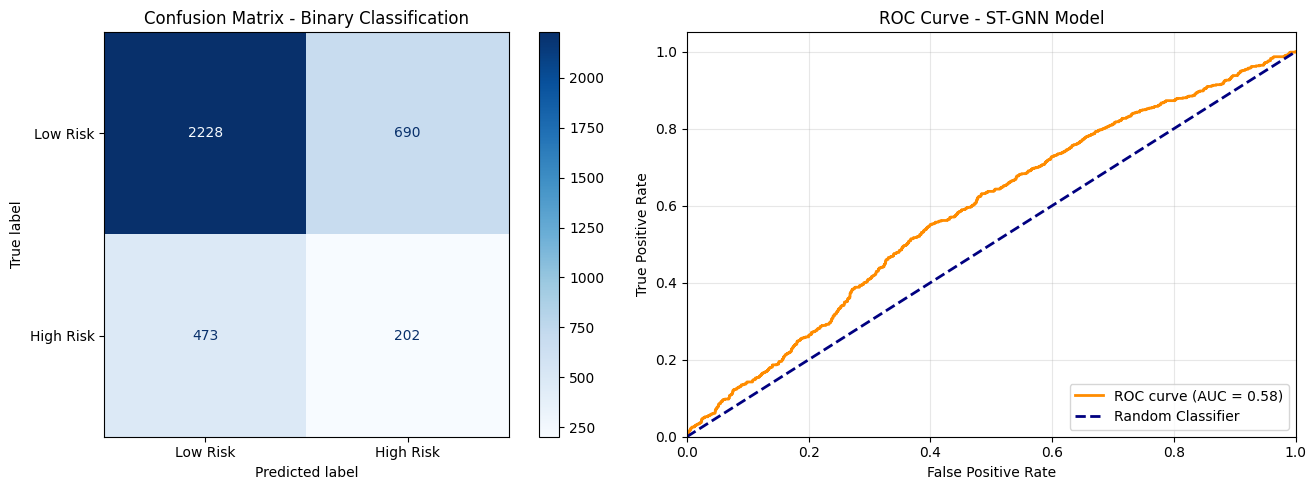

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Creating visualizations for binary classification model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(actuals, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low Risk', 'High Risk'])
disp.plot(ax=axes[0], cmap='Blues')
axes[0].set_title("Confusion Matrix - Binary Classification")

# Plot 2: ROC Curve
fpr, tpr, _ = roc_curve(actuals, probs)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - ST-GNN Model')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
# Feature Importance Analysis using Permutation Importance for Binary Classification

def predict_fn(model, X, device="cpu"):
    model.eval()
    X_tensor = torch.tensor(X, dtype=torch.float32).to(device)

    with torch.no_grad():
        logits = model(X_tensor)
        probs = torch.sigmoid(logits).cpu().numpy()

    return probs

# Permutation Importance Function to assess feature importance by shuffling each feature and measuring the impact on model performance
def permutation_importance(model, X, y, feature_names, device="cpu"):

    baseline_probs = predict_fn(model, X, device).flatten()
    baseline_preds = (baseline_probs > 0.5).astype(int)
    baseline_score = f1_score(y, baseline_preds)

    importances = []

    for i in range(X.shape[2]):  # features dimension

        X_permuted = X.copy()

        # shuffle one feature across ALL samples + time
        perm = np.random.permutation(X_permuted[:, :, i])
        X_permuted[:, :, i] = perm

        probs = predict_fn(model, X_permuted, device).flatten()
        preds = (probs > 0.5).astype(int)
        score = f1_score(y, preds)

        importance = abs(baseline_score - score)
        importances.append(importance)

    return pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False)


importance_df = permutation_importance(
    model,
    X_test,
    y_test,
    feature_names=features,
    device=device
)
print(importance_df)

                        feature  importance
0                    tot_claims    0.020257
2                 tot_drug_cost    0.016973
8          queen_lag_tot_claims    0.016824
7             unemployment_rate    0.013703
3               tot_days_supply    0.013028
9       queen_lag_tot_drug_cost    0.012866
10  queen_lag_unemployment_rate    0.012129
4                  avg_bene_age    0.008964
5           Health_Outcome_Rank    0.007076
6            Health_Factor_Rank    0.006197
1               tot_30day_fills    0.003956


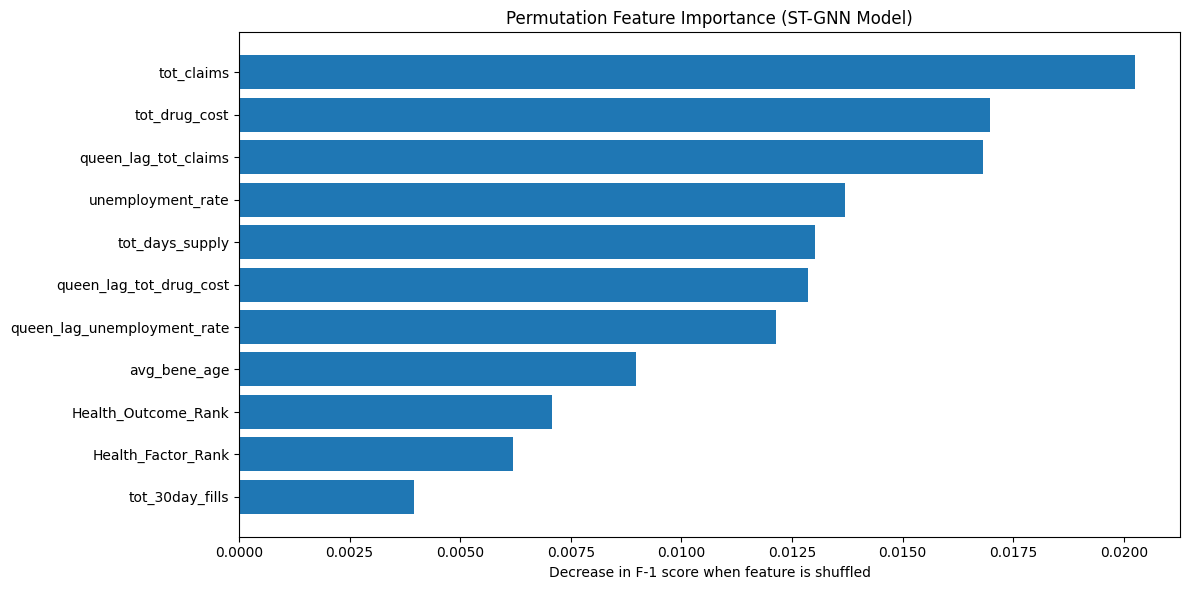

In [32]:
plt.figure(figsize=(12, 6))

plt.barh(
    importance_df["feature"],
    importance_df["importance"]
)

plt.gca().invert_yaxis()

plt.title("Permutation Feature Importance (ST-GNN Model)")
plt.xlabel("Decrease in F-1 score when feature is shuffled")

plt.tight_layout()
plt.show()

## ST-GNN Modeling Summary

This notebook trained and evaluated a Spatial-Temporal Graph Neural Network model for pharmacy desert risk prediction.

Completed steps:
• Created PAP, TDF, and Desert Formation Risk target label.
• Used Queen contiguity to create spatial lag features from neighboring counties.
• Built 3-year county sequences for spatial-temporal modeling.
• Scaled input features and prepared PyTorch datasets.
• Trained the ST-GNN model using BCEWithLogitsLoss and Adam optimizer.
• Evaluated the model using accuracy, precision, recall, F1-score, confusion matrix, and ROC-AUC.
• Generated ROC curve, confusion matrix, and permutation feature importance plot.

Key finding:
ST-GNN added neighboring-county spatial context and detected more High-Risk cases than LSTM, but precision and recall remained weak. The ROC-AUC showed weak but slightly better-than-random class separation.

Next step:
The next notebook will extend the modeling using higher-order network models such as HGNN and Tensor Train.